***Solving the Travelling Salesman Problem (TSP) using Particle Swarm Optimization (PSO)***

In [7]:
from google.colab import files
uploaded = files.upload()


Saving tsp_dataset.csv to tsp_dataset.csv


In [11]:
import csv
import ast
import math
import random


# ========================== LOAD DATASET ==========================

def load_tsp_instance_from_kaggle(csv_path, instance_index=0):
    with open(csv_path, newline='', encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for idx, row in enumerate(reader):
            if idx == instance_index:
                coords_list = ast.literal_eval(row["city_coordinates"])
                dist_matrix = ast.literal_eval(row["distance_matrix"])
                return {
                    "num_cities": int(row["num_cities"]),
                    "coords": coords_list,
                    "distance_matrix": dist_matrix,
                    "optimal": float(row["total_distance"])
                }
    raise ValueError("Index not found!")


# ========================== TSP FUNCTIONS ==========================
"""
    Compute the total distance of a tour using the distance matrix.
    We also add the edge from the last city back to the first city.
    """
def tour_length(tour, dist):
    return sum(dist[tour[i]][tour[(i + 1) % len(tour)]] for i in range(len(tour)))


"""Create a random permutation of n cities """
def random_tour(n):
    t = list(range(n))
    random.shuffle(t)
    return t

"""
    Compute a list of swaps that transforms tour a into tour b.

    This is used as our 'difference' between two tours.
    The result is a list of (i, j) indices that we will swap.
    """
def tour_difference(a, b):
    a = a[:]
    swaps = []
    pos = {city: i for i, city in enumerate(a)}
    for i in range(len(a)):
        if a[i] != b[i]:
            j = pos[b[i]]
            swaps.append((i, j))
            # apply swap in the local copy and update positions
            a[i], a[j] = a[j], a[i]
            pos[a[i]] = i
            pos[a[j]] = j
    return swaps

"""
    Apply a sequence of swap operations (velocity) to a tour.
    Returns a new tour.
    """
def apply_velocity(tour, velocity):
    t = tour[:]
    for i, j in velocity:
        t[i], t[j] = t[j], t[i]
    return t


# ========================== PSO IMPLEMENTATION ==========================

def pso_tsp(dist, n, swarm_size=50, iterations=300, w=0.7, c1=0.5, c2=0.5):
    """
    Parameters
    ----------
    dist : 2D list
        Distance matrix dist[i][j] = distance from city i to city j.
    n : int
        Number of cities in the TSP instance.
    swarm_size : int
        Number of particles (candidate solutions).
    iterations : int
        Number of PSO iterations.
    w : float
        Inertia weight (how much of the old velocity we keep).
    c1 : float
        Cognitive coefficient (attraction to personal best).
    c2 : float
        Social coefficient (attraction to global best).
    seed : int or None
        (Not used here, but could be added for reproducibility.)

    Returns
    -------
    gbest : list[int]
        Best tour found by the swarm.
    gbest_fit : float
        Length of the best tour.
    history : list[float]
        History of the global best fitness per iteration (for convergence plot).
    """

    class Particle:
        def __init__(self):
            self.tour = random_tour(n)
            self.velocity = []
            # Personal best (pbest): best tour and fitness seen by this particle
            self.pbest = self.tour[:]
            self.pbest_fit = tour_length(self.tour, dist)

    # 1) Initialize swarm with random tours
    swarm = [Particle() for _ in range(swarm_size)]
    # 2) Initialize global best (gbest) from all pbests
    best_particle = min(swarm, key=lambda p: p.pbest_fit)
    gbest = best_particle.pbest[:]
    gbest_fit = best_particle.pbest_fit
    history = [gbest_fit]

    # ------------------ PSO main loop ------------------ #
    for _ in range(iterations):
        for p in swarm:
          # 2a) Compute "difference" to personal best and global best
            diff_p = tour_difference(p.tour, p.pbest)
            diff_g = tour_difference(p.tour, gbest)

            # 2b) New velocity = part of old velocity (inertia)
            k1 = min(len(diff_p), max(1, int(c1 * len(diff_p)))) if diff_p else 0
            k2 = min(len(diff_g), max(1, int(c2 * len(diff_g)))) if diff_g else 0
            # 2b) New velocity = part of old velocity (inertia)

            p.velocity = p.velocity[: int(w * len(p.velocity))]
            if diff_p and k1 > 0:
                p.velocity += random.sample(diff_p, k1)
            if diff_g and k2 > 0:
                p.velocity += random.sample(diff_g, k2)

            # 2c) Apply velocity (swap operations) to get new tour
            new_tour = apply_velocity(p.tour, p.velocity)
            # Evaluate the new tour
            fit = tour_length(new_tour, dist)

            # Update personal best
            if fit < p.pbest_fit:
                p.pbest_fit = fit
                p.pbest = new_tour[:]

            # Move particle to new position
            p.tour = new_tour

        # 3) After updating all particles, update the global best
        best_particle = min(swarm, key=lambda p: p.pbest_fit)
        if best_particle.pbest_fit < gbest_fit:
            gbest = best_particle.pbest[:]
            gbest_fit = best_particle.pbest_fit

        history.append(gbest_fit)

    return gbest, gbest_fit, history




In [12]:
# ========================== MAIN EXPERIMENT ==========================

import time

csv_path = "tsp_dataset.csv"

# Shared PSO settings
POP_SIZE = 50
ITERATIONS = 300

# Choose which instances to test
instances_to_test = [0, 1]   # you can add more, e.g. [0, 1, 2, 3]

for instance_index in instances_to_test:

    # Load dataset instance
    data = load_tsp_instance_from_kaggle(csv_path, instance_index)
    n = data["num_cities"]
    dist = data["distance_matrix"]

    # Run PSO and measure time
    start_pso = time.time()
    best_tour, best_cost, history_pso = pso_tsp(
        dist,
        n,
        swarm_size=POP_SIZE,
        iterations=ITERATIONS
    )
    end_pso = time.time()
    time_pso = end_pso - start_pso

    # Print results for this instance
    print("\n=================== PSO Results ===================")
    print("Instance index:", instance_index)
    print("Optimal (from dataset):", data["optimal"])
    print("PSO Best distance found:", best_cost)
    print("PSO Best tour:", best_tour)
    print("PSO Execution time (s):", time_pso)



=================== PSO Results ===================
Instance index: 0
Optimal (from dataset): 2966.177188233671
PSO Best distance found: 2303.370252416083
PSO Best tour: [3, 1, 10, 17, 51, 34, 44, 7, 30, 26, 8, 32, 28, 6, 52, 36, 46, 33, 47, 39, 42, 37, 12, 0, 27, 35, 5, 13, 41, 50, 38, 16, 43, 22, 24, 19, 45, 11, 53, 21, 54, 31, 49, 14, 29, 20, 48, 25, 9, 15, 40, 4, 18, 23, 2]
PSO Execution time (s): 1.0799744129180908

=================== PSO Results ===================
Instance index: 1
Optimal (from dataset): 2170.736410510506
PSO Best distance found: 1543.6195792787973
PSO Best tour: [13, 26, 19, 18, 29, 16, 22, 27, 20, 2, 31, 35, 32, 11, 30, 14, 23, 15, 17, 21, 4, 5, 7, 34, 33, 3, 10, 28, 6, 25, 9, 8, 1, 12, 0, 36, 24]
PSO Execution time (s): 0.7166926860809326


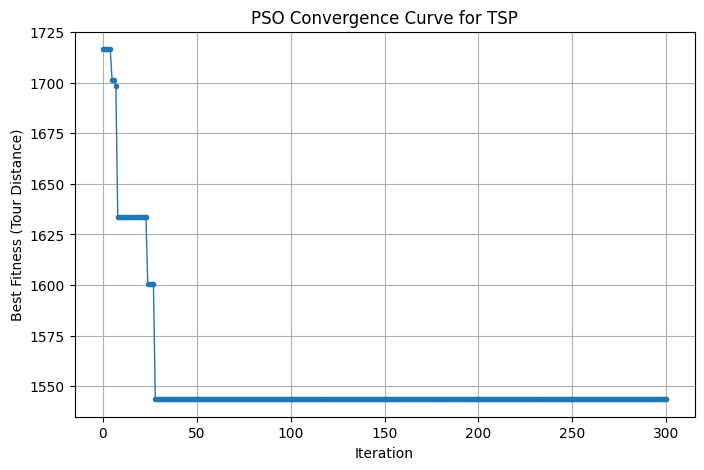

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_pso, marker='o', markersize=3, linewidth=1)
plt.title("PSO Convergence Curve for TSP")
plt.xlabel("Iteration")
plt.ylabel("Best Fitness (Tour Distance)")
plt.grid(True)
plt.show()
